In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/vaishnavishinde/.cache/kagglehub/datasets/uciml/sms-spam-collection-dataset/versions/1


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import nltk
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [29]:
df = pd.read_csv("/Users/vaishnavishinde/.cache/kagglehub/datasets/uciml/sms-spam-collection-dataset/versions/1/spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [30]:
df = df[['v1','v2']]
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [31]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vaishnavishinde/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vaishnavishinde/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [32]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    text = [word for word in text if word.isalnum()]
    
    text = [word for word in text if word not in stopwords.words('english')]
    
    text = [ps.stem(word) for word in text]
    
    return " ".join(text)

In [33]:
df['cleaned'] = df['message'].apply(clean_text)
df.head()

,label,message,cleaned
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [34]:
vectorizer = TfidfVectorizer(max_features=3000)

X_train_tfidf = vectorizer.fit_transform(df['cleaned'])

In [35]:
y = df['label']
y = df["label"].map({"ham": 0, "spam": 1})

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train_tfidf, y, test_size=0.2, random_state=42
)

In [38]:
nb = MultinomialNB()
svm = SVC(probability=True)
lr = LogisticRegression()

In [39]:
nb.fit(X_train, y_train)
svm.fit(X_train, y_train)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
with open("models/naive_bayes_model.pkl", "wb") as f:
    pickle.dump(nb, f)
with open("models/svm_model.pkl", "wb") as f:
    pickle.dump(svm, f)
with open("models/logistic_regression_model.pkl", "wb") as f: 
    pickle.dump(lr, f)
with open("models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

In [ ]:
# with open("models/label_encoder.pkl", "wb") as f:
#     pickle.dump(encoder, f)

In [42]:
y_pred_nb = nb.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_lr = lr.predict(X_test)

In [43]:
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)

In [44]:
print("Naive Bayes Accuracy:", acc_nb)
print("Logistic Regression Accuracy:", acc_lr)
print("SVM Accuracy:", acc_svm)

Naive Bayes Accuracy: 0.9775784753363229
Logistic Regression Accuracy: 0.9461883408071748
SVM Accuracy: 0.9730941704035875


In [45]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_svm = confusion_matrix(y_test, y_pred_svm)

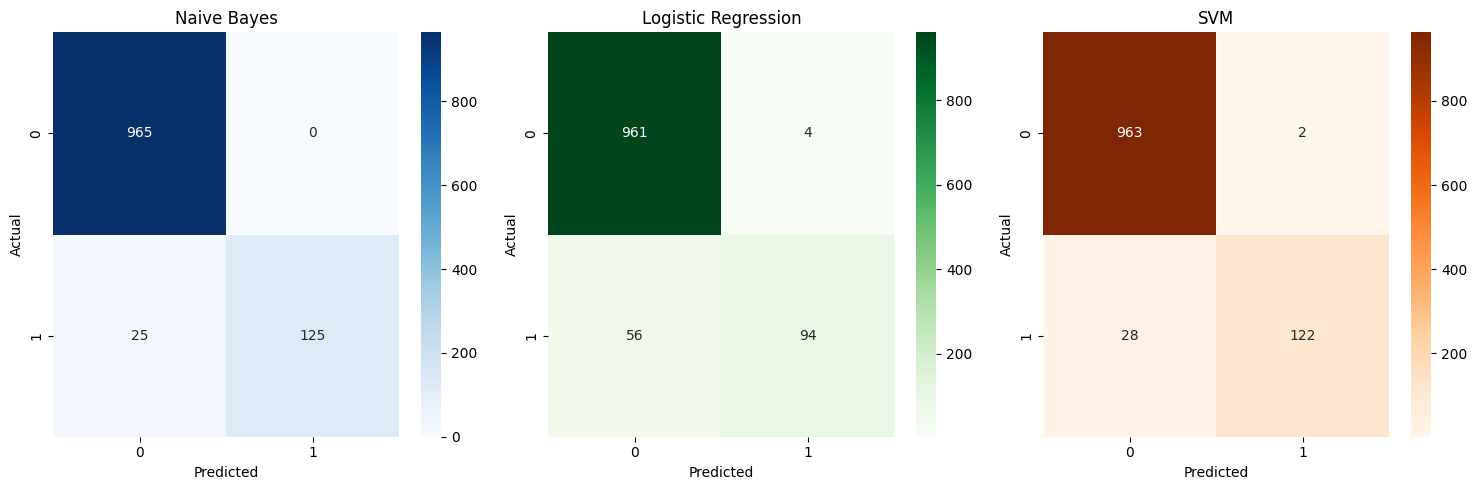

In [46]:
plt.figure(figsize=(15,5))

# Naive Bayes
plt.subplot(1,3,1)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Logistic Regression
plt.subplot(1,3,2)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# SVM
plt.subplot(1,3,3)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges')
plt.title("SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

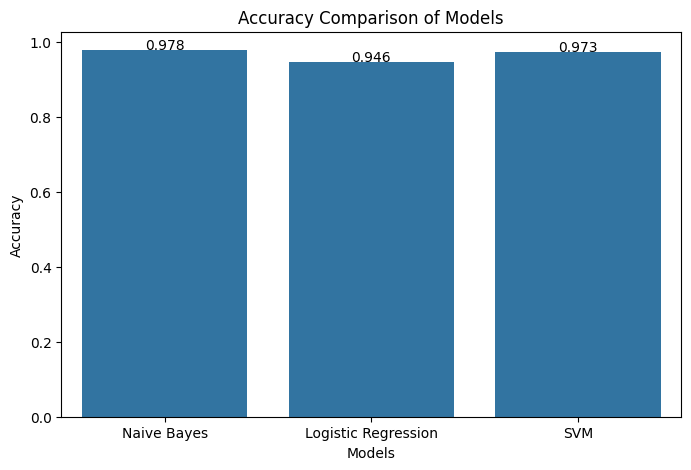

In [47]:
plt.figure(figsize=(8,5))

models = ['Naive Bayes', 'Logistic Regression', 'SVM']
accuracy = [acc_nb, acc_lr, acc_svm]

ax = sns.barplot(x=models, y=accuracy)

for i, v in enumerate(accuracy):
    ax.text(i, v + 0.001, f"{v:.3f}", ha='center')

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()